# Non-Parametric Reliability Feature Extraction

This notebook demonstrates non-parametric approaches to extract reliability features for ML:
1. **Savitzky-Golay Filter** - Polynomial smoothing with derivative computation
2. **Moving Average** - Simple rolling window smoothing
3. **Gaussian Smoothing** - Gaussian kernel convolution
4. **LOESS (Local Regression)** - Locally weighted polynomial regression

**Key Advantage**: No need for parametric model assumptions (no β, λ, etc.). 
The derivative of the smoothed cumulative failure curve directly gives us the failure rate!


In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
%matplotlib inline


## Why Non-Parametric Methods?

**Advantages over parametric models (Crow-AMSAA, etc.):**
- ✅ No assumptions about failure distribution
- ✅ Automatically adapts to data patterns
- ✅ No need to find optimal change points for piecewise models
- ✅ Simple and computationally efficient
- ✅ Derivative gives direct failure rate estimate
- ✅ Preserves important features while reducing noise
- ✅ Better for ML feature extraction (no model-specific parameters)


In [100]:
class SavitzkyGolayReliability:
    """
    Extract reliability features using Savitzky-Golay filter.
    Uses polynomial fitting in a sliding window to smooth data and compute derivatives.
    """
    
    def __init__(self, window_length=None, polyorder=3):
        """
        Initialize the filter.
        
        Parameters:
        -----------
        window_length : int, optional
            Length of filter window (must be odd). If None, auto-selects based on data size
        polyorder : int
            Order of polynomial used to fit samples (default: 3)
        """
        self.window_length = window_length
        self.polyorder = polyorder
        self.fitted = False
        self.time_points = None
        self.cumulative_smooth = None
        self.failure_rate = None
    
    def fit(self, failure_times, censoring_time=None, time_resolution=None):
        """Fit Savitzky-Golay filter to failure data."""
        failure_times = np.sort(failure_times)
        n = len(failure_times)
        
        if n < 3:
            raise ValueError("Need at least 3 failures to apply Savitzky-Golay filter")
        
        if censoring_time is None:
            censoring_time = failure_times[-1]
        
        # Create cumulative failure data
        actual_cumulative = np.arange(1, n + 1)
        
        # Interpolate to regular time grid for better smoothing
        if time_resolution is None:
            time_resolution = max(50, n * 10)
        
        self.time_points = np.linspace(0, censoring_time, time_resolution)
        
        # Interpolate cumulative failures to regular grid
        interp_func = interp1d(
            failure_times, actual_cumulative, 
            kind='linear', bounds_error=False, fill_value=(0, n)
        )
        cumulative_interp = interp_func(self.time_points)
        cumulative_interp = np.maximum.accumulate(cumulative_interp)  # Ensure monotonic
        
        # Auto-select window length if not provided
        if self.window_length is None:
            suggested = int(time_resolution * 0.15)
            if suggested % 2 == 0:
                suggested += 1
            self.window_length = max(5, min(suggested, time_resolution - 1))
            if self.window_length % 2 == 0:
                self.window_length += 1
        
        # Ensure window_length is valid
        if self.window_length >= len(cumulative_interp):
            self.window_length = len(cumulative_interp) - 1
            if self.window_length % 2 == 0:
                self.window_length -= 1
        
        if self.window_length < self.polyorder + 1:
            self.window_length = self.polyorder + 1
            if self.window_length % 2 == 0:
                self.window_length += 1
        
        # Apply Savitzky-Golay filter to smooth cumulative failures
        self.cumulative_smooth = savgol_filter(
            cumulative_interp, window_length=self.window_length,
            polyorder=self.polyorder, mode='interp'
        )
        self.cumulative_smooth = np.maximum.accumulate(self.cumulative_smooth)
        
        # Compute derivative to get failure rate
        dt = self.time_points[1] - self.time_points[0]
        self.failure_rate = savgol_filter(
            cumulative_interp, window_length=self.window_length,
            polyorder=self.polyorder, deriv=1, delta=dt, mode='interp'
        )
        self.failure_rate = np.maximum(self.failure_rate, 0)
        
        self.fitted = True
        return self
    
    def predict_cumulative(self, time):
        """Predict cumulative failures at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        interp_func = interp1d(
            self.time_points, self.cumulative_smooth,
            kind='linear', bounds_error=False,
            fill_value=(0, self.cumulative_smooth[-1])
        )
        return interp_func(time)
    
    def predict_failure_rate(self, time):
        """Predict failure rate at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        interp_func = interp1d(
            self.time_points, self.failure_rate,
            kind='linear', bounds_error=False,
            fill_value=(self.failure_rate[0], self.failure_rate[-1])
        )
        return interp_func(time)
    
    def extract_features(self):
        """Extract features from smoothed curve and failure rate for ML."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        
        features = {}
        features['total_failures'] = self.cumulative_smooth[-1]
        features['avg_failure_rate'] = np.mean(self.failure_rate)
        features['std_failure_rate'] = np.std(self.failure_rate)
        
        # Trend indicators
        if len(self.failure_rate) > 1:
            slope, intercept, r_value, p_value, _ = stats.linregress(
                self.time_points, self.failure_rate
            )
            features['failure_rate_slope'] = slope
            features['failure_rate_trend_r2'] = r_value ** 2
        
        # Percentiles
        features['failure_rate_p25'] = np.percentile(self.failure_rate, 25)
        features['failure_rate_p50'] = np.percentile(self.failure_rate, 50)
        features['failure_rate_p75'] = np.percentile(self.failure_rate, 75)
        features['failure_rate_p90'] = np.percentile(self.failure_rate, 90)
        
        # Rate of change in failure rate (second derivative)
        if len(self.failure_rate) > 1:
            dt = self.time_points[1] - self.time_points[0]
            second_deriv = np.gradient(self.failure_rate, dt)
            features['failure_rate_acceleration'] = np.mean(second_deriv)
        
        # Time-based features
        total_time = self.time_points[-1]
        features['total_time'] = total_time
        features['failures_per_unit_time'] = features['total_failures'] / total_time if total_time > 0 else 0
        
        # Early vs late period comparison
        mid_point = len(self.time_points) // 2
        early_rate = np.mean(self.failure_rate[:mid_point])
        late_rate = np.mean(self.failure_rate[mid_point:])
        features['early_period_rate'] = early_rate
        features['late_period_rate'] = late_rate
        features['rate_change_ratio'] = late_rate / early_rate if early_rate > 0 else 0
        
        # Variability
        features['failure_rate_cv'] = features['std_failure_rate'] / features['avg_failure_rate'] if features['avg_failure_rate'] > 0 else 0
        features['peak_failure_rate'] = np.max(self.failure_rate)
        
        return features
    
    def extract_timeseries_features(self, n_lags=5, window_sizes=[7, 14, 30]):
        """
        Extract time series features for ML models.
        
        Parameters:
        -----------
        n_lags : int
            Number of lag features to create (default: 5)
        window_sizes : list
            Window sizes for rolling statistics (default: [7, 14, 30])
        
        Returns:
        --------
        features : dict
            Time series features including raw data and derived features
        """
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        
        features = {}
        
        # 1. Raw time series data (for direct use in LSTM/RNN/Transformer models)
        features['timeseries_data'] = {
            'time_points': self.time_points.copy(),
            'failure_rate': self.failure_rate.copy(),
            'cumulative_failures': self.cumulative_smooth.copy()
        }
        
        # 2. Lag features (previous values)
        for lag in range(1, n_lags + 1):
            if len(self.failure_rate) > lag:
                lag_values = np.roll(self.failure_rate, lag)
                lag_values[:lag] = np.nan
                features[f'failure_rate_lag_{lag}'] = lag_values
        
        # 3. Rolling window statistics
        for window in window_sizes:
            if len(self.failure_rate) >= window:
                rolling_mean = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).mean()
                rolling_std = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).std()
                rolling_min = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).min()
                rolling_max = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).max()
                
                features[f'rolling_mean_{window}'] = rolling_mean.values
                features[f'rolling_std_{window}'] = rolling_std.values
                features[f'rolling_min_{window}'] = rolling_min.values
                features[f'rolling_max_{window}'] = rolling_max.values
        
        # 4. Autocorrelation features (temporal dependencies)
        autocorr_features = {}
        for lag in [1, 7, 14, 30]:
            if len(self.failure_rate) > lag:
                try:
                    acf = np.corrcoef(self.failure_rate[:-lag], self.failure_rate[lag:])[0, 1]
                    autocorr_features[f'autocorr_lag_{lag}'] = acf if not np.isnan(acf) else 0
                except:
                    autocorr_features[f'autocorr_lag_{lag}'] = 0
        features['autocorrelation'] = autocorr_features
        
        # 5. Volatility features (GARCH-like measures)
        if len(self.failure_rate) > 1:
            # Calculate returns (percentage change)
            returns = np.diff(self.failure_rate) / (self.failure_rate[:-1] + 1e-10)
            features['volatility'] = np.std(returns)
            features['mean_absolute_change'] = np.mean(np.abs(returns))
            
            # Volatility clustering (correlation of squared returns)
            if len(returns) > 1:
                try:
                    vol_cluster = np.corrcoef(returns[:-1]**2, returns[1:]**2)[0, 1]
                    features['volatility_clustering'] = vol_cluster if not np.isnan(vol_cluster) else 0
                except:
                    features['volatility_clustering'] = 0
            else:
                features['volatility_clustering'] = 0
        
        # 6. Trend decomposition
        if len(self.failure_rate) > 1:
            # Detrend using moving average
            trend_window = min(30, len(self.failure_rate) // 4)
            trend = pd.Series(self.failure_rate).rolling(
                window=trend_window, center=True, min_periods=1
            ).mean()
            detrended = self.failure_rate - trend.values
            
            features['trend_component'] = trend.values
            features['detrended_component'] = detrended
            features['trend_strength'] = np.var(trend.values) / (np.var(self.failure_rate) + 1e-10)
            features['detrended_std'] = np.std(detrended)
        
        # 7. Change point detection (simple variance-based)
        if len(self.failure_rate) > 10:
            # Split into segments and compare variance
            n_segments = 3
            segment_size = len(self.failure_rate) // n_segments
            segment_vars = []
            for i in range(n_segments):
                start = i * segment_size
                end = (i + 1) * segment_size if i < n_segments - 1 else len(self.failure_rate)
                segment_vars.append(np.var(self.failure_rate[start:end]))
            features['variance_change'] = np.std(segment_vars) / (np.mean(segment_vars) + 1e-10)
        else:
            features['variance_change'] = 0
        
        # 8. Time-based features
        features['time_since_start'] = self.time_points - self.time_points[0]
        features['time_normalized'] = self.time_points / (self.time_points[-1] + 1e-10)
        
        # 9. Summary statistics for time series
        features['timeseries_summary'] = {
            'mean': np.mean(self.failure_rate),
            'std': np.std(self.failure_rate),
            'min': np.min(self.failure_rate),
            'max': np.max(self.failure_rate),
            'range': np.max(self.failure_rate) - np.min(self.failure_rate),
            'cv': np.std(self.failure_rate) / (np.mean(self.failure_rate) + 1e-10),
            'skewness': stats.skew(self.failure_rate),
            'kurtosis': stats.kurtosis(self.failure_rate)
        }
        
        return features


In [101]:
class MovingAverageReliability:
    """
    Extract reliability features using moving average smoothing.
    Simple but effective for noisy data.
    """
    
    def __init__(self, window_size=None):
        """
        Initialize the smoother.
        
        Parameters:
        -----------
        window_size : int, optional
            Size of moving average window. If None, auto-selects.
        """
        self.window_size = window_size
        self.fitted = False
        self.time_points = None
        self.cumulative_smooth = None
        self.failure_rate = None
    
    def fit(self, failure_times, censoring_time=None, time_resolution=None):
        """Fit moving average to failure data."""
        failure_times = np.sort(failure_times)
        n = len(failure_times)
        
        if n < 3:
            raise ValueError("Need at least 3 failures")
        
        if censoring_time is None:
            censoring_time = failure_times[-1]
        
        actual_cumulative = np.arange(1, n + 1)
        
        if time_resolution is None:
            time_resolution = max(50, n * 10)
        
        self.time_points = np.linspace(0, censoring_time, time_resolution)
        
        # Interpolate to regular grid
        interp_func = interp1d(
            failure_times, actual_cumulative,
            kind='linear', bounds_error=False, fill_value=(0, n)
        )
        cumulative_interp = interp_func(self.time_points)
        cumulative_interp = np.maximum.accumulate(cumulative_interp)
        
        # Auto-select window size
        if self.window_size is None:
            self.window_size = max(3, int(time_resolution * 0.1))
        
        # Apply moving average
        self.cumulative_smooth = pd.Series(cumulative_interp).rolling(
            window=self.window_size, center=True, min_periods=1
        ).mean().values
        
        # Compute derivative using numerical differentiation
        dt = self.time_points[1] - self.time_points[0]
        self.failure_rate = np.gradient(self.cumulative_smooth, dt)
        self.failure_rate = np.maximum(self.failure_rate, 0)
        
        self.fitted = True
        return self
    
    def predict_cumulative(self, time):
        """Predict cumulative failures at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        interp_func = interp1d(
            self.time_points, self.cumulative_smooth,
            kind='linear', bounds_error=False,
            fill_value=(0, self.cumulative_smooth[-1])
        )
        return interp_func(time)
    
    def predict_failure_rate(self, time):
        """Predict failure rate at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        interp_func = interp1d(
            self.time_points, self.failure_rate,
            kind='linear', bounds_error=False,
            fill_value=(self.failure_rate[0], self.failure_rate[-1])
        )
        return interp_func(time)
    
    def extract_features(self):
        """Extract features for ML."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        
        features = {}
        features['total_failures'] = self.cumulative_smooth[-1]
        features['avg_failure_rate'] = np.mean(self.failure_rate)
        features['std_failure_rate'] = np.std(self.failure_rate)
        
        # Trend indicators
        if len(self.failure_rate) > 1:
            slope, intercept, r_value, p_value, _ = stats.linregress(
                self.time_points, self.failure_rate
            )
            features['failure_rate_slope'] = slope
            features['failure_rate_trend_r2'] = r_value ** 2
        
        # Percentiles
        features['failure_rate_p25'] = np.percentile(self.failure_rate, 25)
        features['failure_rate_p50'] = np.percentile(self.failure_rate, 50)
        features['failure_rate_p75'] = np.percentile(self.failure_rate, 75)
        features['failure_rate_p90'] = np.percentile(self.failure_rate, 90)
        
        # Rate of change in failure rate (second derivative)
        if len(self.failure_rate) > 1:
            dt = self.time_points[1] - self.time_points[0]
            second_deriv = np.gradient(self.failure_rate, dt)
            features['failure_rate_acceleration'] = np.mean(second_deriv)
        
        # Time-based features
        total_time = self.time_points[-1]
        features['total_time'] = total_time
        features['failures_per_unit_time'] = features['total_failures'] / total_time if total_time > 0 else 0
        
        # Early vs late period comparison
        mid_point = len(self.time_points) // 2
        early_rate = np.mean(self.failure_rate[:mid_point])
        late_rate = np.mean(self.failure_rate[mid_point:])
        features['early_period_rate'] = early_rate
        features['late_period_rate'] = late_rate
        features['rate_change_ratio'] = late_rate / early_rate if early_rate > 0 else 0
        
        # Variability
        features['failure_rate_cv'] = features['std_failure_rate'] / features['avg_failure_rate'] if features['avg_failure_rate'] > 0 else 0
        features['peak_failure_rate'] = np.max(self.failure_rate)
        
        return features
    
    def extract_timeseries_features(self, n_lags=5, window_sizes=[7, 14, 30]):
        """Extract time series features for ML models."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        
        features = {}
        features['timeseries_data'] = {
            'time_points': self.time_points.copy(),
            'failure_rate': self.failure_rate.copy(),
            'cumulative_failures': self.cumulative_smooth.copy()
        }
        
        for lag in range(1, n_lags + 1):
            if len(self.failure_rate) > lag:
                lag_values = np.roll(self.failure_rate, lag)
                lag_values[:lag] = np.nan
                features[f'failure_rate_lag_{lag}'] = lag_values
        
        for window in window_sizes:
            if len(self.failure_rate) >= window:
                rolling_mean = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).mean()
                rolling_std = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).std()
                rolling_min = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).min()
                rolling_max = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).max()
                features[f'rolling_mean_{window}'] = rolling_mean.values
                features[f'rolling_std_{window}'] = rolling_std.values
                features[f'rolling_min_{window}'] = rolling_min.values
                features[f'rolling_max_{window}'] = rolling_max.values
        
        autocorr_features = {}
        for lag in [1, 7, 14, 30]:
            if len(self.failure_rate) > lag:
                try:
                    acf = np.corrcoef(self.failure_rate[:-lag], self.failure_rate[lag:])[0, 1]
                    autocorr_features[f'autocorr_lag_{lag}'] = acf if not np.isnan(acf) else 0
                except:
                    autocorr_features[f'autocorr_lag_{lag}'] = 0
        features['autocorrelation'] = autocorr_features
        
        if len(self.failure_rate) > 1:
            returns = np.diff(self.failure_rate) / (self.failure_rate[:-1] + 1e-10)
            features['volatility'] = np.std(returns)
            features['mean_absolute_change'] = np.mean(np.abs(returns))
            if len(returns) > 1:
                try:
                    vol_cluster = np.corrcoef(returns[:-1]**2, returns[1:]**2)[0, 1]
                    features['volatility_clustering'] = vol_cluster if not np.isnan(vol_cluster) else 0
                except:
                    features['volatility_clustering'] = 0
            else:
                features['volatility_clustering'] = 0
        
        if len(self.failure_rate) > 1:
            trend_window = min(30, len(self.failure_rate) // 4)
            trend = pd.Series(self.failure_rate).rolling(window=trend_window, center=True, min_periods=1).mean()
            detrended = self.failure_rate - trend.values
            features['trend_component'] = trend.values
            features['detrended_component'] = detrended
            features['trend_strength'] = np.var(trend.values) / (np.var(self.failure_rate) + 1e-10)
            features['detrended_std'] = np.std(detrended)
        
        if len(self.failure_rate) > 10:
            n_segments = 3
            segment_size = len(self.failure_rate) // n_segments
            segment_vars = []
            for i in range(n_segments):
                start = i * segment_size
                end = (i + 1) * segment_size if i < n_segments - 1 else len(self.failure_rate)
                segment_vars.append(np.var(self.failure_rate[start:end]))
            features['variance_change'] = np.std(segment_vars) / (np.mean(segment_vars) + 1e-10)
        else:
            features['variance_change'] = 0
        
        features['time_since_start'] = self.time_points - self.time_points[0]
        features['time_normalized'] = self.time_points / (self.time_points[-1] + 1e-10)
        
        features['timeseries_summary'] = {
            'mean': np.mean(self.failure_rate),
            'std': np.std(self.failure_rate),
            'min': np.min(self.failure_rate),
            'max': np.max(self.failure_rate),
            'range': np.max(self.failure_rate) - np.min(self.failure_rate),
            'cv': np.std(self.failure_rate) / (np.mean(self.failure_rate) + 1e-10),
            'skewness': stats.skew(self.failure_rate),
            'kurtosis': stats.kurtosis(self.failure_rate)
        }
        
        return features


In [102]:
class GaussianSmoothingReliability:
    """
    Extract reliability features using Gaussian kernel smoothing.
    Good for preserving smooth trends.
    """
    
    def __init__(self, sigma=None):
        """
        Initialize the smoother.
        
        Parameters:
        -----------
        sigma : float, optional
            Standard deviation of Gaussian kernel. If None, auto-selects.
        """
        self.sigma = sigma
        self.fitted = False
        self.time_points = None
        self.cumulative_smooth = None
        self.failure_rate = None
    
    def fit(self, failure_times, censoring_time=None, time_resolution=None):
        """Fit Gaussian smoothing to failure data."""
        failure_times = np.sort(failure_times)
        n = len(failure_times)
        
        if n < 3:
            raise ValueError("Need at least 3 failures")
        
        if censoring_time is None:
            censoring_time = failure_times[-1]
        
        actual_cumulative = np.arange(1, n + 1)
        
        if time_resolution is None:
            time_resolution = max(50, n * 10)
        
        self.time_points = np.linspace(0, censoring_time, time_resolution)
        
        # Interpolate to regular grid
        interp_func = interp1d(
            failure_times, actual_cumulative,
            kind='linear', bounds_error=False, fill_value=(0, n)
        )
        cumulative_interp = interp_func(self.time_points)
        cumulative_interp = np.maximum.accumulate(cumulative_interp)
        
        # Auto-select sigma
        if self.sigma is None:
            dt = self.time_points[1] - self.time_points[0]
            self.sigma = max(1.0, dt * 5)  # 5 time steps
        
        # Apply Gaussian smoothing
        self.cumulative_smooth = gaussian_filter1d(
            cumulative_interp, sigma=self.sigma
        )
        self.cumulative_smooth = np.maximum.accumulate(self.cumulative_smooth)
        
        # Compute derivative
        dt = self.time_points[1] - self.time_points[0]
        self.failure_rate = np.gradient(self.cumulative_smooth, dt)
        self.failure_rate = np.maximum(self.failure_rate, 0)
        
        self.fitted = True
        return self
    
    def predict_cumulative(self, time):
        """Predict cumulative failures at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        interp_func = interp1d(
            self.time_points, self.cumulative_smooth,
            kind='linear', bounds_error=False,
            fill_value=(0, self.cumulative_smooth[-1])
        )
        return interp_func(time)
    
    def predict_failure_rate(self, time):
        """Predict failure rate at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        interp_func = interp1d(
            self.time_points, self.failure_rate,
            kind='linear', bounds_error=False,
            fill_value=(self.failure_rate[0], self.failure_rate[-1])
        )
        return interp_func(time)
    
    def extract_features(self):
        """Extract features for ML."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        
        features = {}
        features['total_failures'] = self.cumulative_smooth[-1]
        features['avg_failure_rate'] = np.mean(self.failure_rate)
        features['std_failure_rate'] = np.std(self.failure_rate)
        
        # Trend indicators
        if len(self.failure_rate) > 1:
            slope, intercept, r_value, p_value, _ = stats.linregress(
                self.time_points, self.failure_rate
            )
            features['failure_rate_slope'] = slope
            features['failure_rate_trend_r2'] = r_value ** 2
        
        # Percentiles
        features['failure_rate_p25'] = np.percentile(self.failure_rate, 25)
        features['failure_rate_p50'] = np.percentile(self.failure_rate, 50)
        features['failure_rate_p75'] = np.percentile(self.failure_rate, 75)
        features['failure_rate_p90'] = np.percentile(self.failure_rate, 90)
        
        # Rate of change in failure rate (second derivative)
        if len(self.failure_rate) > 1:
            dt = self.time_points[1] - self.time_points[0]
            second_deriv = np.gradient(self.failure_rate, dt)
            features['failure_rate_acceleration'] = np.mean(second_deriv)
        
        # Time-based features
        total_time = self.time_points[-1]
        features['total_time'] = total_time
        features['failures_per_unit_time'] = features['total_failures'] / total_time if total_time > 0 else 0
        
        # Early vs late period comparison
        mid_point = len(self.time_points) // 2
        early_rate = np.mean(self.failure_rate[:mid_point])
        late_rate = np.mean(self.failure_rate[mid_point:])
        features['early_period_rate'] = early_rate
        features['late_period_rate'] = late_rate
        features['rate_change_ratio'] = late_rate / early_rate if early_rate > 0 else 0
        
        # Variability
        features['failure_rate_cv'] = features['std_failure_rate'] / features['avg_failure_rate'] if features['avg_failure_rate'] > 0 else 0
        features['peak_failure_rate'] = np.max(self.failure_rate)
        
        return features
    
    def extract_timeseries_features(self, n_lags=5, window_sizes=[7, 14, 30]):
        """Extract time series features for ML models."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        
        features = {}
        features['timeseries_data'] = {
            'time_points': self.time_points.copy(),
            'failure_rate': self.failure_rate.copy(),
            'cumulative_failures': self.cumulative_smooth.copy()
        }
        
        for lag in range(1, n_lags + 1):
            if len(self.failure_rate) > lag:
                lag_values = np.roll(self.failure_rate, lag)
                lag_values[:lag] = np.nan
                features[f'failure_rate_lag_{lag}'] = lag_values
        
        for window in window_sizes:
            if len(self.failure_rate) >= window:
                rolling_mean = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).mean()
                rolling_std = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).std()
                rolling_min = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).min()
                rolling_max = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).max()
                features[f'rolling_mean_{window}'] = rolling_mean.values
                features[f'rolling_std_{window}'] = rolling_std.values
                features[f'rolling_min_{window}'] = rolling_min.values
                features[f'rolling_max_{window}'] = rolling_max.values
        
        autocorr_features = {}
        for lag in [1, 7, 14, 30]:
            if len(self.failure_rate) > lag:
                try:
                    acf = np.corrcoef(self.failure_rate[:-lag], self.failure_rate[lag:])[0, 1]
                    autocorr_features[f'autocorr_lag_{lag}'] = acf if not np.isnan(acf) else 0
                except:
                    autocorr_features[f'autocorr_lag_{lag}'] = 0
        features['autocorrelation'] = autocorr_features
        
        if len(self.failure_rate) > 1:
            returns = np.diff(self.failure_rate) / (self.failure_rate[:-1] + 1e-10)
            features['volatility'] = np.std(returns)
            features['mean_absolute_change'] = np.mean(np.abs(returns))
            if len(returns) > 1:
                try:
                    vol_cluster = np.corrcoef(returns[:-1]**2, returns[1:]**2)[0, 1]
                    features['volatility_clustering'] = vol_cluster if not np.isnan(vol_cluster) else 0
                except:
                    features['volatility_clustering'] = 0
            else:
                features['volatility_clustering'] = 0
        
        if len(self.failure_rate) > 1:
            trend_window = min(30, len(self.failure_rate) // 4)
            trend = pd.Series(self.failure_rate).rolling(window=trend_window, center=True, min_periods=1).mean()
            detrended = self.failure_rate - trend.values
            features['trend_component'] = trend.values
            features['detrended_component'] = detrended
            features['trend_strength'] = np.var(trend.values) / (np.var(self.failure_rate) + 1e-10)
            features['detrended_std'] = np.std(detrended)
        
        if len(self.failure_rate) > 10:
            n_segments = 3
            segment_size = len(self.failure_rate) // n_segments
            segment_vars = []
            for i in range(n_segments):
                start = i * segment_size
                end = (i + 1) * segment_size if i < n_segments - 1 else len(self.failure_rate)
                segment_vars.append(np.var(self.failure_rate[start:end]))
            features['variance_change'] = np.std(segment_vars) / (np.mean(segment_vars) + 1e-10)
        else:
            features['variance_change'] = 0
        
        features['time_since_start'] = self.time_points - self.time_points[0]
        features['time_normalized'] = self.time_points / (self.time_points[-1] + 1e-10)
        
        features['timeseries_summary'] = {
            'mean': np.mean(self.failure_rate),
            'std': np.std(self.failure_rate),
            'min': np.min(self.failure_rate),
            'max': np.max(self.failure_rate),
            'range': np.max(self.failure_rate) - np.min(self.failure_rate),
            'cv': np.std(self.failure_rate) / (np.mean(self.failure_rate) + 1e-10),
            'skewness': stats.skew(self.failure_rate),
            'kurtosis': stats.kurtosis(self.failure_rate)
        }
        
        return features


In [103]:
class LOESSReliability:
    """
    Extract reliability features using LOESS (Locally Weighted Scatterplot Smoothing).
    Non-parametric local regression method.
    """
    
    def __init__(self, frac=0.3):
        """
        Initialize LOESS.
        
        Parameters:
        -----------
        frac : float
            Fraction of data to use for each local regression (0-1).
        """
        self.frac = frac
        self.fitted = False
        self.time_points = None
        self.cumulative_smooth = None
        self.failure_rate = None
    
    def _loess_smooth(self, x, y, x_new, frac):
        """Simple LOESS implementation."""
        y_smooth = np.zeros_like(x_new)
        
        for i, xi in enumerate(x_new):
            # Calculate distances
            distances = np.abs(x - xi)
            
            # Use frac fraction of nearest points
            n_neighbors = max(3, int(len(x) * frac))
            if n_neighbors >= len(x):
                weights = np.ones(len(x))
            else:
                # Get threshold distance
                threshold = np.partition(distances, n_neighbors)[n_neighbors]
                # Triangular weights
                weights = np.maximum(0, 1 - distances / (threshold + 1e-10))
                weights[distances > threshold] = 0
            
            # Weighted least squares
            if np.sum(weights) > 0:
                # Simple linear fit
                W = np.diag(weights)
                X = np.vstack([np.ones(len(x)), x]).T
                try:
                    coeffs = np.linalg.lstsq(W @ X, W @ y, rcond=None)[0]
                    y_smooth[i] = coeffs[0] + coeffs[1] * xi
                except:
                    y_smooth[i] = np.average(y, weights=weights)
            else:
                y_smooth[i] = y[np.argmin(distances)]
        
        return y_smooth
    
    def fit(self, failure_times, censoring_time=None, time_resolution=None):
        """Fit LOESS to failure data."""
        failure_times = np.sort(failure_times)
        n = len(failure_times)
        
        if n < 3:
            raise ValueError("Need at least 3 failures")
        
        if censoring_time is None:
            censoring_time = failure_times[-1]
        
        actual_cumulative = np.arange(1, n + 1)
        
        if time_resolution is None:
            time_resolution = max(50, n * 10)
        
        self.time_points = np.linspace(0, censoring_time, time_resolution)
        
        # Apply LOESS smoothing
        self.cumulative_smooth = self._loess_smooth(
            failure_times, actual_cumulative, self.time_points, self.frac
        )
        self.cumulative_smooth = np.maximum.accumulate(self.cumulative_smooth)
        
        # Compute derivative
        dt = self.time_points[1] - self.time_points[0]
        self.failure_rate = np.gradient(self.cumulative_smooth, dt)
        self.failure_rate = np.maximum(self.failure_rate, 0)
        
        self.fitted = True
        return self
    
    def predict_cumulative(self, time):
        """Predict cumulative failures at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        interp_func = interp1d(
            self.time_points, self.cumulative_smooth,
            kind='linear', bounds_error=False,
            fill_value=(0, self.cumulative_smooth[-1])
        )
        return interp_func(time)
    
    def predict_failure_rate(self, time):
        """Predict failure rate at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        interp_func = interp1d(
            self.time_points, self.failure_rate,
            kind='linear', bounds_error=False,
            fill_value=(self.failure_rate[0], self.failure_rate[-1])
        )
        return interp_func(time)
    
    def extract_features(self):
        """Extract features for ML."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        
        features = {}
        features['total_failures'] = self.cumulative_smooth[-1]
        features['avg_failure_rate'] = np.mean(self.failure_rate)
        features['std_failure_rate'] = np.std(self.failure_rate)
        
        # Trend indicators
        if len(self.failure_rate) > 1:
            slope, intercept, r_value, p_value, _ = stats.linregress(
                self.time_points, self.failure_rate
            )
            features['failure_rate_slope'] = slope
            features['failure_rate_trend_r2'] = r_value ** 2
        
        # Percentiles
        features['failure_rate_p25'] = np.percentile(self.failure_rate, 25)
        features['failure_rate_p50'] = np.percentile(self.failure_rate, 50)
        features['failure_rate_p75'] = np.percentile(self.failure_rate, 75)
        features['failure_rate_p90'] = np.percentile(self.failure_rate, 90)
        
        # Rate of change in failure rate (second derivative)
        if len(self.failure_rate) > 1:
            dt = self.time_points[1] - self.time_points[0]
            second_deriv = np.gradient(self.failure_rate, dt)
            features['failure_rate_acceleration'] = np.mean(second_deriv)
        
        # Time-based features
        total_time = self.time_points[-1]
        features['total_time'] = total_time
        features['failures_per_unit_time'] = features['total_failures'] / total_time if total_time > 0 else 0
        
        # Early vs late period comparison
        mid_point = len(self.time_points) // 2
        early_rate = np.mean(self.failure_rate[:mid_point])
        late_rate = np.mean(self.failure_rate[mid_point:])
        features['early_period_rate'] = early_rate
        features['late_period_rate'] = late_rate
        features['rate_change_ratio'] = late_rate / early_rate if early_rate > 0 else 0
        
        # Variability
        features['failure_rate_cv'] = features['std_failure_rate'] / features['avg_failure_rate'] if features['avg_failure_rate'] > 0 else 0
        features['peak_failure_rate'] = np.max(self.failure_rate)
        
        return features
    
    def extract_timeseries_features(self, n_lags=5, window_sizes=[7, 14, 30]):
        """Extract time series features for ML models."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        
        features = {}
        features['timeseries_data'] = {
            'time_points': self.time_points.copy(),
            'failure_rate': self.failure_rate.copy(),
            'cumulative_failures': self.cumulative_smooth.copy()
        }
        
        for lag in range(1, n_lags + 1):
            if len(self.failure_rate) > lag:
                lag_values = np.roll(self.failure_rate, lag)
                lag_values[:lag] = np.nan
                features[f'failure_rate_lag_{lag}'] = lag_values
        
        for window in window_sizes:
            if len(self.failure_rate) >= window:
                rolling_mean = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).mean()
                rolling_std = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).std()
                rolling_min = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).min()
                rolling_max = pd.Series(self.failure_rate).rolling(window=window, min_periods=1).max()
                features[f'rolling_mean_{window}'] = rolling_mean.values
                features[f'rolling_std_{window}'] = rolling_std.values
                features[f'rolling_min_{window}'] = rolling_min.values
                features[f'rolling_max_{window}'] = rolling_max.values
        
        autocorr_features = {}
        for lag in [1, 7, 14, 30]:
            if len(self.failure_rate) > lag:
                try:
                    acf = np.corrcoef(self.failure_rate[:-lag], self.failure_rate[lag:])[0, 1]
                    autocorr_features[f'autocorr_lag_{lag}'] = acf if not np.isnan(acf) else 0
                except:
                    autocorr_features[f'autocorr_lag_{lag}'] = 0
        features['autocorrelation'] = autocorr_features
        
        if len(self.failure_rate) > 1:
            returns = np.diff(self.failure_rate) / (self.failure_rate[:-1] + 1e-10)
            features['volatility'] = np.std(returns)
            features['mean_absolute_change'] = np.mean(np.abs(returns))
            if len(returns) > 1:
                try:
                    vol_cluster = np.corrcoef(returns[:-1]**2, returns[1:]**2)[0, 1]
                    features['volatility_clustering'] = vol_cluster if not np.isnan(vol_cluster) else 0
                except:
                    features['volatility_clustering'] = 0
            else:
                features['volatility_clustering'] = 0
        
        if len(self.failure_rate) > 1:
            trend_window = min(30, len(self.failure_rate) // 4)
            trend = pd.Series(self.failure_rate).rolling(window=trend_window, center=True, min_periods=1).mean()
            detrended = self.failure_rate - trend.values
            features['trend_component'] = trend.values
            features['detrended_component'] = detrended
            features['trend_strength'] = np.var(trend.values) / (np.var(self.failure_rate) + 1e-10)
            features['detrended_std'] = np.std(detrended)
        
        if len(self.failure_rate) > 10:
            n_segments = 3
            segment_size = len(self.failure_rate) // n_segments
            segment_vars = []
            for i in range(n_segments):
                start = i * segment_size
                end = (i + 1) * segment_size if i < n_segments - 1 else len(self.failure_rate)
                segment_vars.append(np.var(self.failure_rate[start:end]))
            features['variance_change'] = np.std(segment_vars) / (np.mean(segment_vars) + 1e-10)
        else:
            features['variance_change'] = 0
        
        features['time_since_start'] = self.time_points - self.time_points[0]
        features['time_normalized'] = self.time_points / (self.time_points[-1] + 1e-10)
        
        features['timeseries_summary'] = {
            'mean': np.mean(self.failure_rate),
            'std': np.std(self.failure_rate),
            'min': np.min(self.failure_rate),
            'max': np.max(self.failure_rate),
            'range': np.max(self.failure_rate) - np.min(self.failure_rate),
            'cv': np.std(self.failure_rate) / (np.mean(self.failure_rate) + 1e-10),
            'skewness': stats.skew(self.failure_rate),
            'kurtosis': stats.kurtosis(self.failure_rate)
        }
        
        return features


## Generate Test Data

Let's use the same data generation function from the previous notebook.


In [104]:
def generate_failure_data(scenario='growth', n_failures=20, total_time=365, seed=None):
    """
    Generate synthetic failure data.
    """
    if seed is not None:
        np.random.seed(seed)
    
    if scenario == 'growth':
        beta_true = 0.7
        lambda_true = n_failures / (total_time ** beta_true)
        u = np.random.uniform(0, 1, n_failures)
        failure_times = total_time * (u ** (1 / beta_true))
        failure_times = np.sort(failure_times)
        
    elif scenario == 'constant':
        beta_true = 1.0
        lambda_true = n_failures / total_time
        u = np.random.uniform(0, 1, n_failures)
        failure_times = -np.log(1 - u) / lambda_true
        failure_times = failure_times[failure_times < total_time]
        failure_times = np.sort(failure_times)
        
    elif scenario == 'decay':
        beta_true = 1.5
        lambda_true = n_failures / (total_time ** beta_true)
        u = np.random.uniform(0, 1, n_failures)
        failure_times = total_time * (u ** (1 / beta_true))
        failure_times = np.sort(failure_times)
    
    elif scenario == 'piecewise':
        change_point = total_time * 0.4
        beta1 = 0.6
        n1 = int(n_failures * 0.4)
        lambda1 = n1 / (change_point ** beta1)
        u1 = np.random.uniform(0, 1, n1)
        times1 = change_point * (u1 ** (1 / beta1))
        times1 = np.sort(times1)
        
        beta2 = 1.4
        n2 = n_failures - n1
        cumulative_at_change = lambda1 * (change_point ** beta1)
        lambda2 = (cumulative_at_change + n2) / (total_time ** beta2)
        
        u2 = np.random.uniform(0, 1, n2)
        times2_relative = (total_time - change_point) * (u2 ** (1 / beta2))
        times2 = change_point + times2_relative
        times2 = np.sort(times2)
        
        failure_times = np.concatenate([times1, times2])
        failure_times = failure_times[failure_times < total_time]
        failure_times = np.sort(failure_times)
    
    return failure_times, total_time


## Compare All Methods on Same Data

Let's test all smoothing methods on the same dataset and visualize:
1. **Cumulative failures** (smoothed)
2. **Failure rate** (derivative) - This is the key output!


In [105]:
# Generate test data
test_failures, test_censoring = generate_failure_data(
    scenario='piecewise',
    n_failures=30,
    total_time=365,
    seed=100
)

print(f"Generated {len(test_failures)} failures over {test_censoring:.1f} days")
print(f"First 5 failures: {test_failures[:5]}")
print(f"Last 5 failures: {test_failures[-5:]}")

# Fit all methods
methods = {
    'Savitzky-Golay': SavitzkyGolayReliability(),
    'Moving Average': MovingAverageReliability(),
    'Gaussian Smoothing': GaussianSmoothingReliability(),
    'LOESS': LOESSReliability()
}

results = {}
for name, method in methods.items():
    try:
        method.fit(test_failures, test_censoring)
        results[name] = {
            'model': method,
            'features': method.extract_features()
        }
        print(f"✓ {name} fitted successfully")
    except Exception as e:
        print(f"✗ {name} failed: {e}")

# Actual data for plotting
actual_cumulative = np.arange(1, len(test_failures) + 1)


Generated 30 failures over 365.0 days
First 5 failures: [ 0.01938269  4.35570357  5.29665808 10.76373504 17.32694403]
Last 5 failures: [334.67754104 335.43101464 335.66712072 355.53644202 361.6458432 ]
✓ Savitzky-Golay fitted successfully
✓ Moving Average fitted successfully
✓ Gaussian Smoothing fitted successfully
✓ LOESS fitted successfully


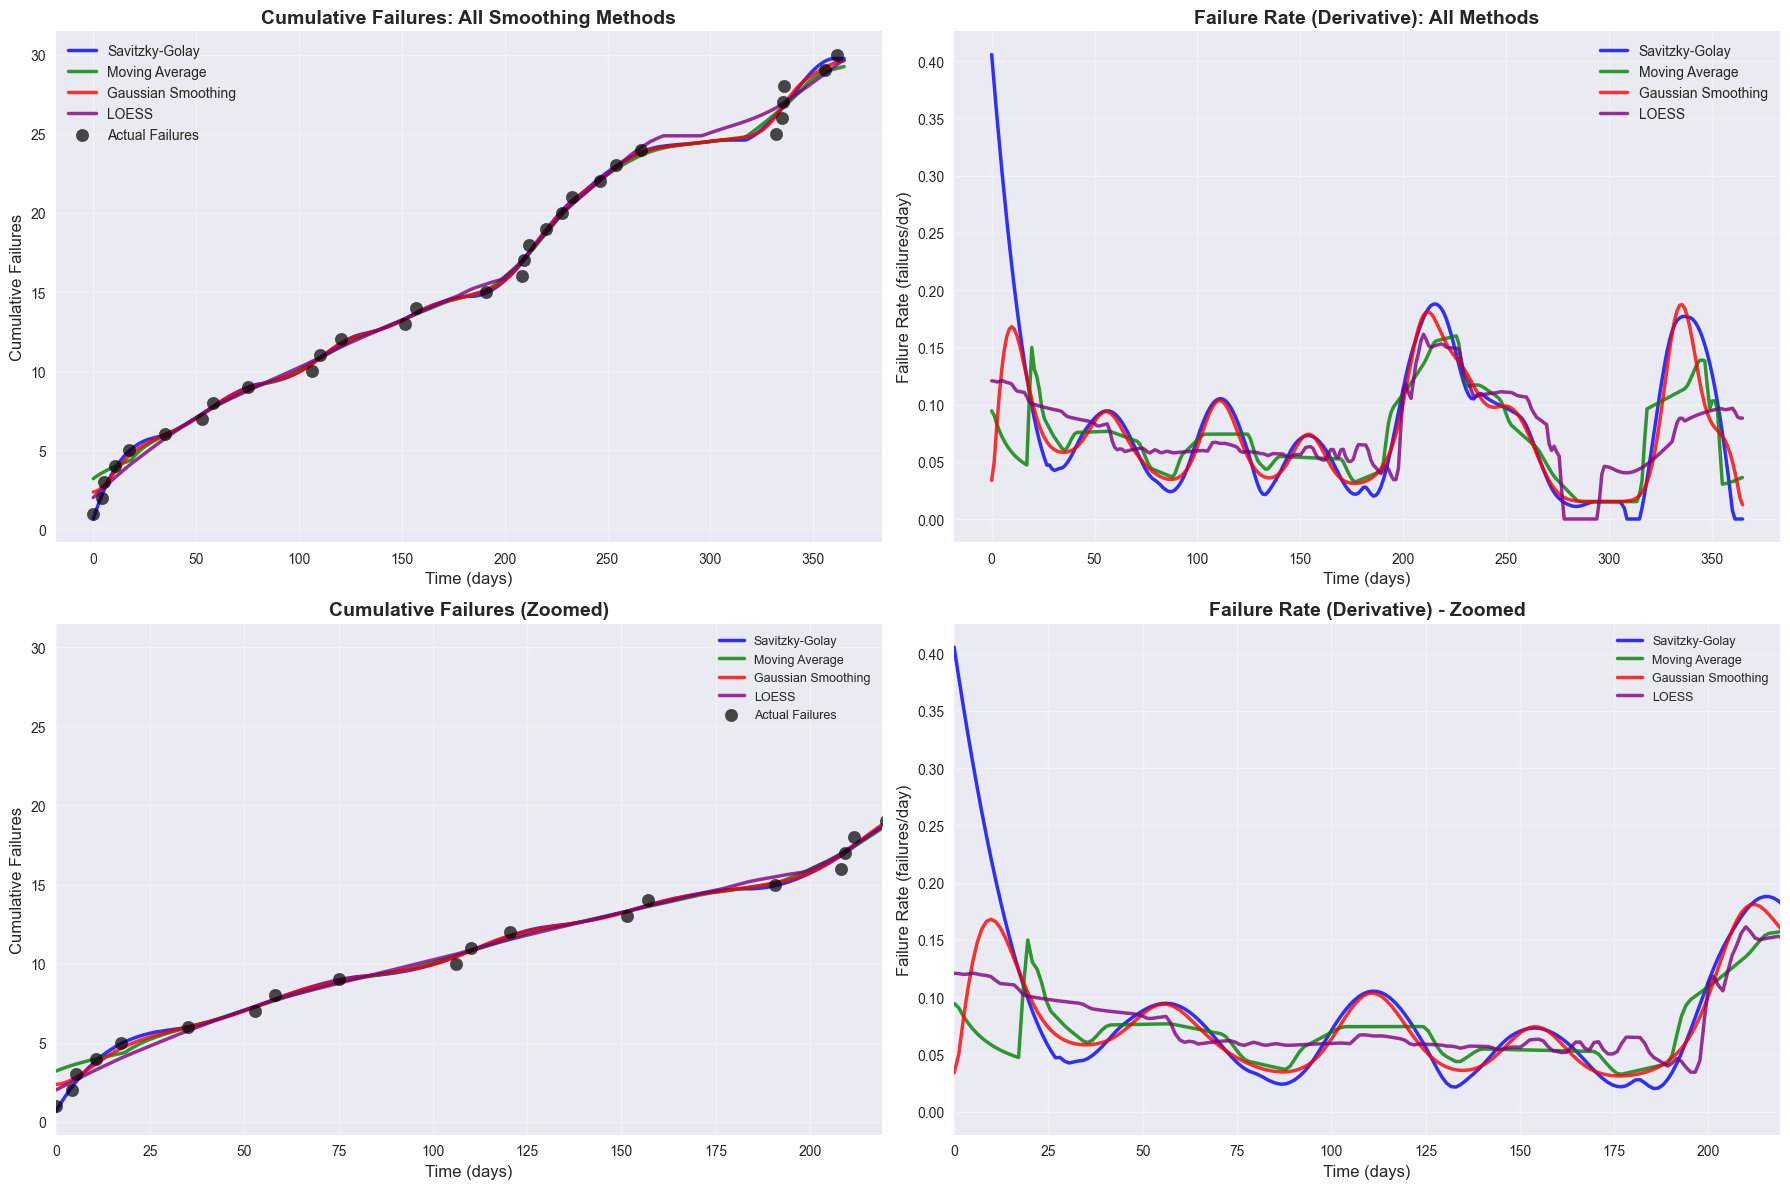


KEY INSIGHT: The derivative of cumulative failures = Failure Rate!


In [106]:
# Create comprehensive comparison plots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot 1: Cumulative Failures - All Methods
ax = axes[0, 0]
colors = ['blue', 'green', 'red', 'purple', 'orange']
for idx, (name, result) in enumerate(results.items()):
    model = result['model']
    ax.plot(model.time_points, model.cumulative_smooth,
           linewidth=2.5, label=name, alpha=0.8, color=colors[idx % len(colors)])

ax.scatter(test_failures, actual_cumulative, color='black',
          s=80, zorder=5, label='Actual Failures', alpha=0.7)
ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Cumulative Failures', fontsize=12)
ax.set_title('Cumulative Failures: All Smoothing Methods', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: Failure Rate (Derivative) - All Methods - THIS IS THE KEY PLOT!
ax = axes[0, 1]
for idx, (name, result) in enumerate(results.items()):
    model = result['model']
    ax.plot(model.time_points, model.failure_rate,
           linewidth=2.5, label=name, alpha=0.8, color=colors[idx % len(colors)])

ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Failure Rate (failures/day)', fontsize=12)
ax.set_title('Failure Rate (Derivative): All Methods', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 3: Zoomed view of cumulative failures
ax = axes[1, 0]
for idx, (name, result) in enumerate(results.items()):
    model = result['model']
    ax.plot(model.time_points, model.cumulative_smooth,
           linewidth=2.5, label=name, alpha=0.8, color=colors[idx % len(colors)])

ax.scatter(test_failures, actual_cumulative, color='black',
          s=80, zorder=5, label='Actual Failures', alpha=0.7)
ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Cumulative Failures', fontsize=12)
ax.set_title('Cumulative Failures (Zoomed)', fontsize=14, fontweight='bold')
ax.set_xlim(0, test_censoring * 0.6)  # First 60% of time
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 4: Zoomed view of failure rate
ax = axes[1, 1]
for idx, (name, result) in enumerate(results.items()):
    model = result['model']
    ax.plot(model.time_points, model.failure_rate,
           linewidth=2.5, label=name, alpha=0.8, color=colors[idx % len(colors)])

ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Failure Rate (failures/day)', fontsize=12)
ax.set_title('Failure Rate (Derivative) - Zoomed', fontsize=14, fontweight='bold')
ax.set_xlim(0, test_censoring * 0.6)  # First 60% of time
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("KEY INSIGHT: The derivative of cumulative failures = Failure Rate!")
print("="*70)


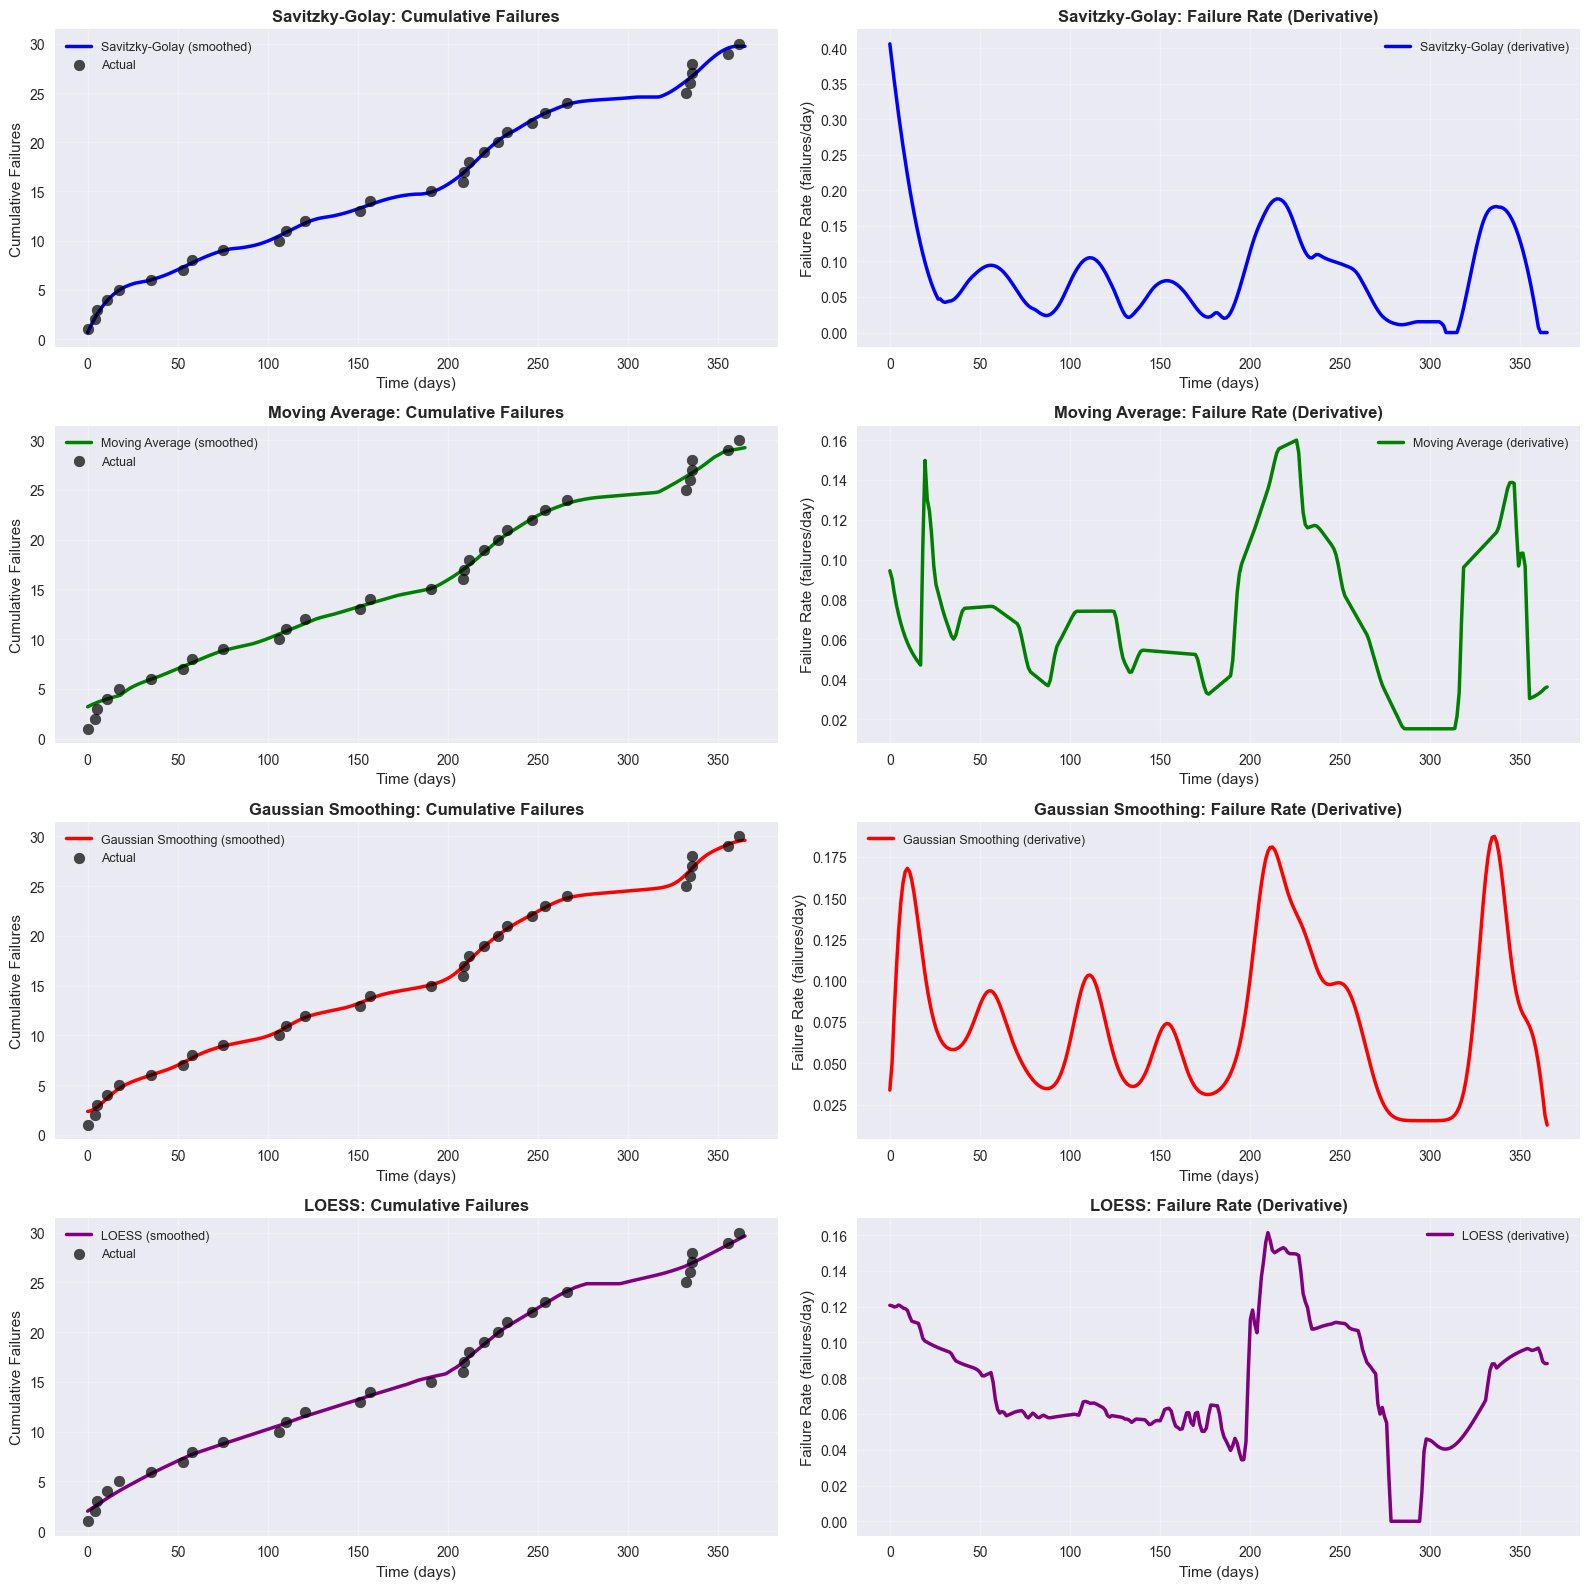

In [107]:
# Detailed comparison of each method side-by-side
n_methods = len(results)
fig, axes = plt.subplots(n_methods, 2, figsize=(16, 4 * n_methods))

for idx, (name, result) in enumerate(results.items()):
    model = result['model']
    
    # Left: Cumulative
    ax = axes[idx, 0]
    ax.plot(model.time_points, model.cumulative_smooth,
           linewidth=2.5, label=f'{name} (smoothed)', color=colors[idx % len(colors)])
    ax.scatter(test_failures, actual_cumulative, color='black',
              s=60, zorder=5, label='Actual', alpha=0.7)
    ax.set_xlabel('Time (days)', fontsize=11)
    ax.set_ylabel('Cumulative Failures', fontsize=11)
    ax.set_title(f'{name}: Cumulative Failures', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Right: Failure Rate (Derivative)
    ax = axes[idx, 1]
    ax.plot(model.time_points, model.failure_rate,
           linewidth=2.5, label=f'{name} (derivative)', color=colors[idx % len(colors)])
    ax.set_xlabel('Time (days)', fontsize=11)
    ax.set_ylabel('Failure Rate (failures/day)', fontsize=11)
    ax.set_title(f'{name}: Failure Rate (Derivative)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Feature Extraction for ML

All methods extract similar features that can be used directly in ML models without needing parametric model parameters.


## Feature Descriptions

Below is a detailed explanation of each extracted feature and what it means for ML applications:

### Basic Statistics
- **`total_failures`**: Total number of failures observed over the observation period. Higher values indicate more frequent failures.
- **`total_time`**: Total observation time (in days). Used to normalize other time-based features.
- **`failures_per_unit_time`**: Average failure frequency (failures/day). Simple metric for overall reliability.

### Failure Rate Statistics
- **`avg_failure_rate`**: Mean failure rate over time (failures/day). Overall intensity of failures.
- **`std_failure_rate`**: Standard deviation of failure rate. Measures variability - higher values indicate more inconsistent failure patterns.
- **`peak_failure_rate`**: Maximum failure rate observed. Indicates worst-case failure intensity.
- **`failure_rate_cv`**: Coefficient of Variation (std/mean). Normalized variability measure:
  - CV < 0.5: Relatively stable failure rate
  - CV > 1.0: High variability (unstable)
  - CV = 0: Constant failure rate

### Failure Rate Distribution (Percentiles)
- **`failure_rate_p25`**: 25th percentile of failure rate. Lower quartile - 25% of time has failure rate below this.
- **`failure_rate_p50`**: 50th percentile (median) of failure rate. Middle value - half the time above/below.
- **`failure_rate_p75`**: 75th percentile of failure rate. Upper quartile - 25% of time has failure rate above this.
- **`failure_rate_p90`**: 90th percentile of failure rate. 90% of time has failure rate below this value.

### Trend Indicators
- **`failure_rate_slope`**: Linear trend of failure rate over time (failures/day²):
  - **Positive**: Failure rate increasing (degrading reliability)
  - **Negative**: Failure rate decreasing (improving reliability)
  - **Near zero**: Relatively constant failure rate
- **`failure_rate_trend_r2`**: R² of linear regression (0-1). Measures how well a linear trend fits:
  - **High R² (>0.5)**: Strong linear trend
  - **Low R² (<0.1)**: Weak or non-linear patterns
- **`failure_rate_acceleration`**: Rate of change of failure rate (second derivative). Measures how quickly the trend is changing:
  - **Positive**: Trend is accelerating (getting worse faster)
  - **Negative**: Trend is decelerating (improving more slowly)

### Temporal Comparison Features
- **`early_period_rate`**: Average failure rate in first half of observation period.
- **`late_period_rate`**: Average failure rate in second half of observation period.
- **`rate_change_ratio`**: Ratio of late/early period rates:
  - **> 1.0**: Failure rate increased (degrading)
  - **< 1.0**: Failure rate decreased (improving)
  - **= 1.0**: No change

### ML Interpretation Tips
- **For PM Effectiveness**: Compare `rate_change_ratio` before/after PM implementation. Values < 1.0 suggest PM is working.
- **For Predictive Models**: Use `failure_rate_slope` and `failure_rate_trend_r2` to detect trends. Low R² suggests need for non-linear models.
- **For Risk Assessment**: `peak_failure_rate` and `failure_rate_p90` indicate worst-case scenarios.
- **For Stability Analysis**: `failure_rate_cv` shows consistency. Lower CV = more predictable patterns.


Extracted Features for ML (all methods):
 total_failures  avg_failure_rate  std_failure_rate  failure_rate_slope  failure_rate_trend_r2  failure_rate_p25  failure_rate_p50  failure_rate_p75  failure_rate_p90  failure_rate_acceleration  total_time  failures_per_unit_time  early_period_rate  late_period_rate  rate_change_ratio  failure_rate_cv  peak_failure_rate             method
      29.752267          0.080740          0.064889           -0.000095               0.023829          0.031158          0.069065          0.104659          0.169912                  -0.001144       365.0                0.081513           0.078645          0.082835           1.053279         0.803687           0.405849     Savitzky-Golay
      29.244235          0.071305          0.036274            0.000007               0.000367          0.045826          0.068241          0.097351          0.120983                  -0.000164       365.0                0.080121           0.063442          0.079168           

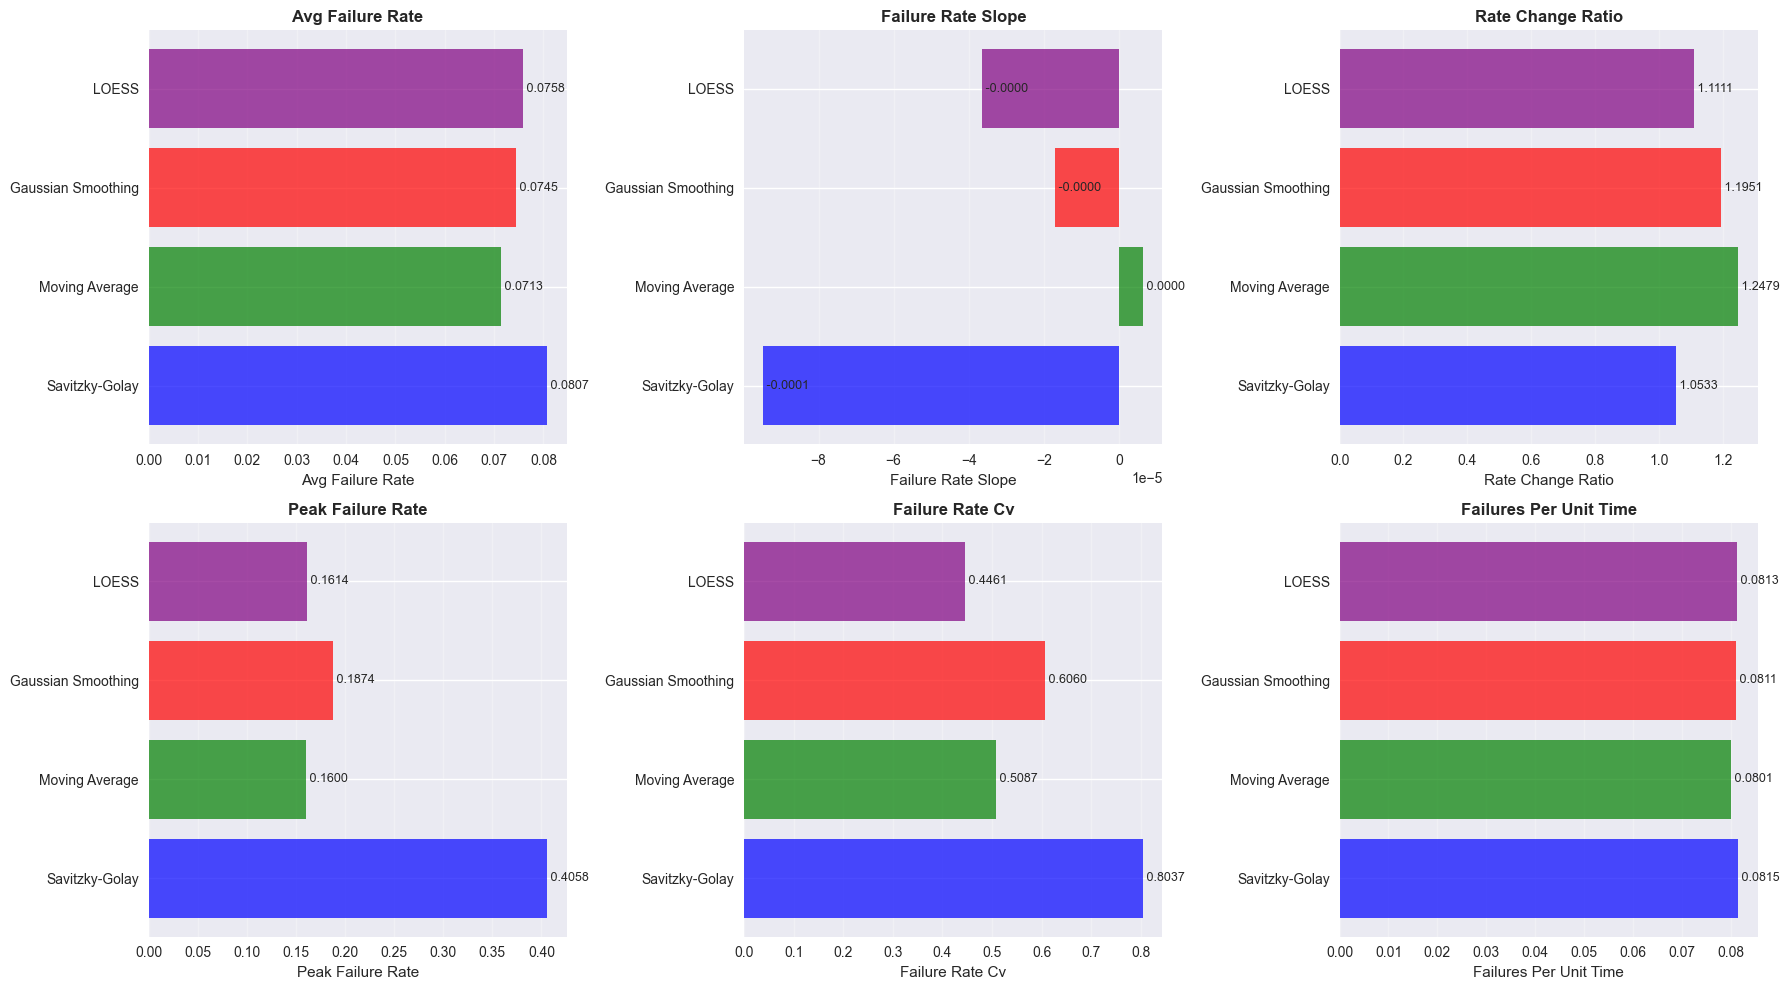

In [108]:
# Extract and compare features from all methods
all_features = []

for name, result in results.items():
    features = result['features'].copy()
    features['method'] = name
    all_features.append(features)

features_df = pd.DataFrame(all_features)
print("Extracted Features for ML (all methods):")
print("=" * 80)
print(features_df.to_string(index=False))

# Create a comparison visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Key features to compare
key_features = ['avg_failure_rate', 'failure_rate_slope', 'rate_change_ratio', 
                'peak_failure_rate', 'failure_rate_cv', 'failures_per_unit_time']

for idx, feat in enumerate(key_features):
    ax = axes[idx // 3, idx % 3]
    if feat in features_df.columns:
        values = features_df[feat].values
        methods = features_df['method'].values
        
        bars = ax.barh(methods, values, color=colors[:len(methods)], alpha=0.7)
        ax.set_xlabel(feat.replace('_', ' ').title(), fontsize=11)
        ax.set_title(f'{feat.replace("_", " ").title()}', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='x')
        
        # Add value labels
        for i, (bar, val) in enumerate(zip(bars, values)):
            ax.text(val, i, f' {val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


## Advanced Time Series ML Method Comparison

For time series ML models (LSTM, RNN, ARIMA, Transformer, etc.), we evaluate methods based on:
1. **Time Series Smoothness** - How smooth is the failure rate series (critical for neural networks)
2. **Temporal Dependencies** - Strength of autocorrelation (important for ARIMA-like models)
3. **Signal Quality** - Signal-to-noise ratio (affects all time series models)
4. **Stationarity** - Variance stability over time (important for statistical models)
5. **Feature Completeness** - Ability to extract time series features


TIME SERIES ML METHOD COMPARISON
                    smoothness  temporal_dependencies  signal_quality  stationarity  feature_completeness   ml_score
LOESS                 0.995552               0.578949        0.882754      0.697348                   1.0  80.350340
Moving Average        0.993382               0.596479        0.825685      0.660774                   1.0  79.121148
Savitzky-Golay        0.998481               0.527953        0.829773      0.749186                   1.0  78.626249
Gaussian Smoothing    0.998529               0.533377        0.806891      0.755592                   1.0  78.428872


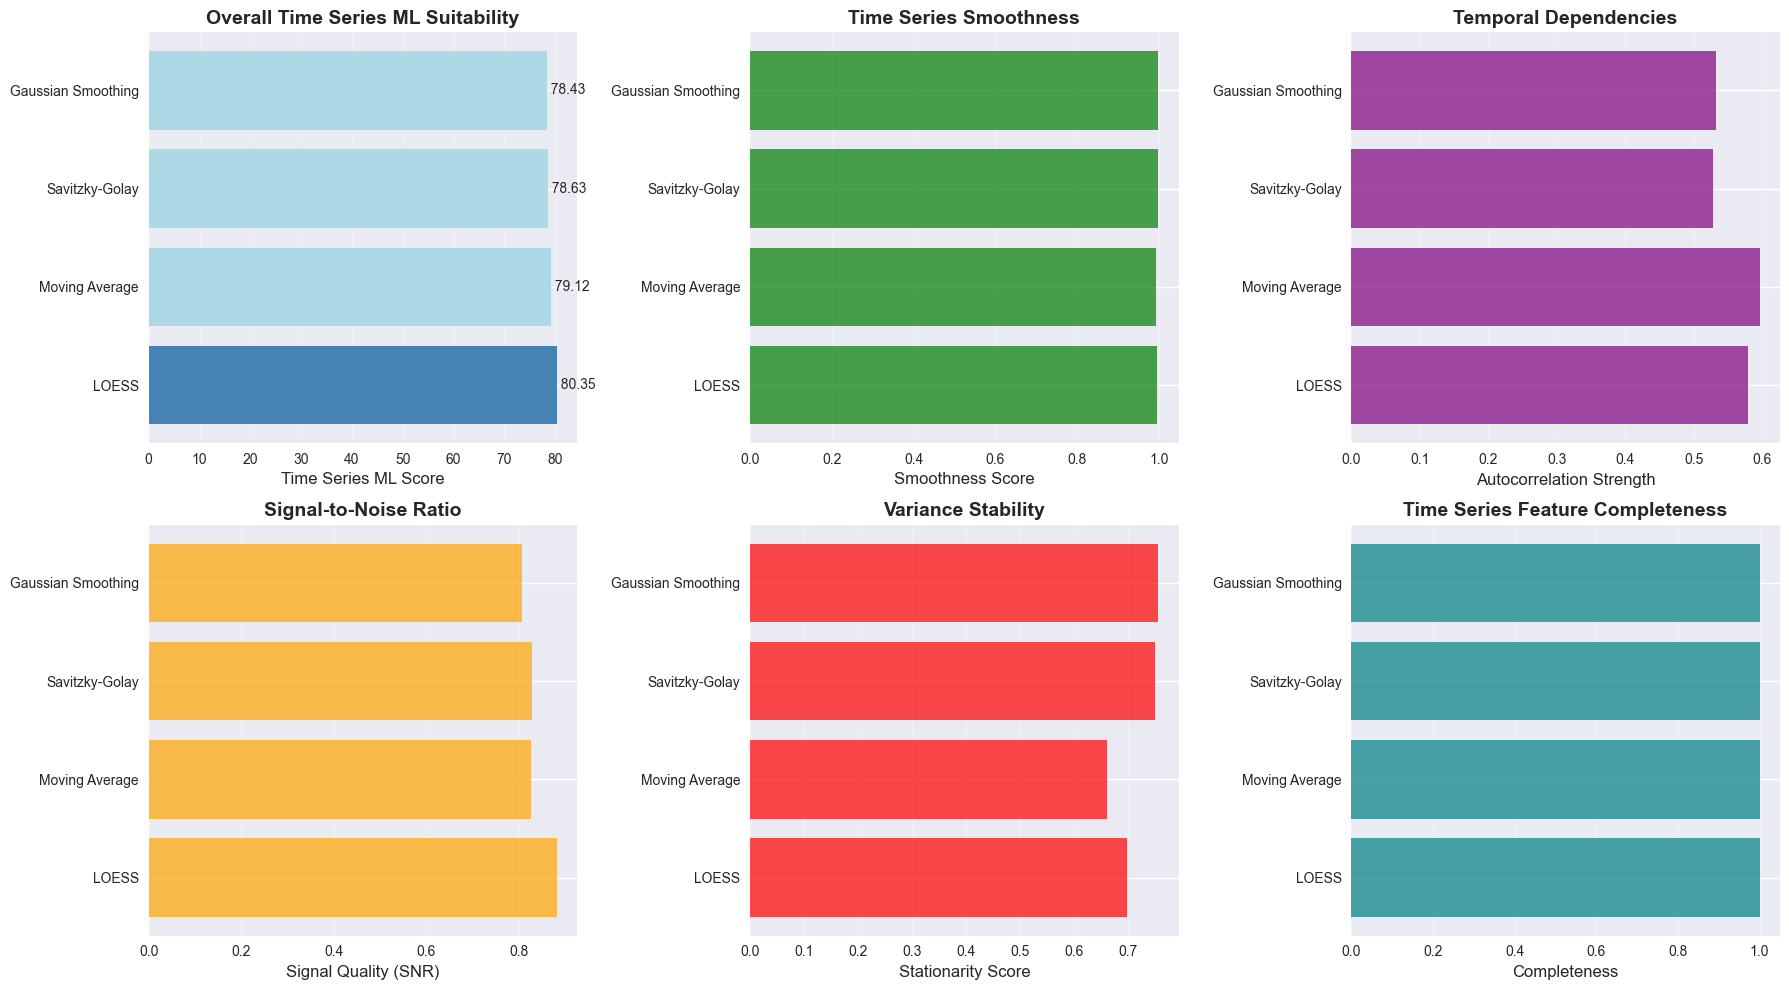


FINAL TIME SERIES ML RECOMMENDATION:
Best method for Time Series ML: LOESS
Time Series ML Score: 80.35/100
  - Smoothness: 0.9956
  - Temporal Dependencies: 0.5789
  - Signal Quality: 0.8828
  - Stationarity: 0.6973
  - Feature Completeness: 1.0000


In [109]:
# Advanced comparison for Time Series ML
def compare_methods_for_timeseries_ml(features_dict, models_dict):
    """
    Compare methods on Time Series ML-specific criteria:
    1. Time Series Smoothness - How smooth is the failure rate series (important for LSTM/RNN)
    2. Temporal Dependencies - Strength of autocorrelation (important for ARIMA-like models)
    3. Signal Quality - Signal-to-noise ratio (important for all time series models)
    4. Stationarity - How stationary the series is (important for statistical models)
    """
    comparison = {}
    
    for method_name, features in features_dict.items():
        metrics = {}
        model = models_dict[method_name]
        
        if not hasattr(model, 'failure_rate') or not model.fitted:
            continue
        
        failure_rate = model.failure_rate
        
        # 1. Time Series Smoothness (inverse of second derivative variance)
        # Lower variance in changes = smoother series = better for time series models
        if len(failure_rate) > 2:
            first_diff = np.diff(failure_rate)
            second_diff = np.diff(first_diff)
            smoothness = 1 / (1 + np.std(second_diff))  # Higher = smoother
        else:
            smoothness = 0
        metrics['smoothness'] = smoothness
        
        # 2. Temporal Dependencies (Autocorrelation strength)
        # Higher autocorrelation = stronger temporal patterns = better for time series models
        autocorr_sum = 0
        autocorr_count = 0
        for lag in [1, 7, 14, 30]:
            if len(failure_rate) > lag:
                try:
                    acf = np.corrcoef(failure_rate[:-lag], failure_rate[lag:])[0, 1]
                    if not np.isnan(acf):
                        autocorr_sum += abs(acf)
                        autocorr_count += 1
                except:
                    pass
        metrics['temporal_dependencies'] = autocorr_sum / autocorr_count if autocorr_count > 0 else 0
        
        # 3. Signal Quality (Signal-to-Noise Ratio)
        # Higher SNR = cleaner signal = better for ML models
        if len(failure_rate) > 1:
            signal_power = np.var(failure_rate)
            # Estimate noise as variance of detrended series
            if len(failure_rate) > 10:
                trend = pd.Series(failure_rate).rolling(
                    window=min(30, len(failure_rate)//4), center=True, min_periods=1
                ).mean()
                noise = failure_rate - trend.values
                noise_power = np.var(noise)
                snr = signal_power / (noise_power + 1e-10)
                metrics['signal_quality'] = 1 / (1 + 1/snr)  # Normalized
            else:
                metrics['signal_quality'] = 0.5
        else:
            metrics['signal_quality'] = 0
        
        # 4. Stationarity (variance stability over time)
        # More stationary = better for ARIMA/statistical models
        if len(failure_rate) > 10:
            # Split into segments and compare variance
            n_segments = 3
            segment_size = len(failure_rate) // n_segments
            segment_vars = []
            for i in range(n_segments):
                start = i * segment_size
                end = (i + 1) * segment_size if i < n_segments - 1 else len(failure_rate)
                segment_vars.append(np.var(failure_rate[start:end]))
            # Lower variance in segment variances = more stationary
            stationarity = 1 / (1 + np.std(segment_vars) / (np.mean(segment_vars) + 1e-10))
        else:
            stationarity = 0.5
        metrics['stationarity'] = stationarity
        
        # 5. Feature Completeness (for time series features)
        # Check if time series features can be extracted
        try:
            ts_features = model.extract_timeseries_features()
            completeness = 1.0 if 'timeseries_data' in ts_features else 0.0
        except:
            completeness = 0.0
        metrics['feature_completeness'] = completeness
        
        # Weighted Time Series ML score
        # For time series ML, smoothness and temporal dependencies are most important
        ml_score = (
            metrics['smoothness'] * 0.30 +
            metrics['temporal_dependencies'] * 0.30 +
            metrics['signal_quality'] * 0.20 +
            metrics['stationarity'] * 0.15 +
            metrics['feature_completeness'] * 0.05
        ) * 100
        
        comparison[method_name] = {
            **metrics,
            'ml_score': ml_score
        }
    
    return comparison

# Run time series ML comparison
ml_comparison = compare_methods_for_timeseries_ml(
    {name: result['features'] for name, result in results.items()},
    {name: result['model'] for name, result in results.items()}
)

ml_df = pd.DataFrame(ml_comparison).T
ml_df = ml_df.sort_values('ml_score', ascending=False)

print("="*80)
print("TIME SERIES ML METHOD COMPARISON")
print("="*80)
print(ml_df.to_string())

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Overall ML Score
ax = axes[0, 0]
methods = ml_df.index
scores = ml_df['ml_score'].values
bars = ax.barh(methods, scores, color=['steelblue' if s == max(scores) else 'lightblue' for s in scores])
ax.set_xlabel('Time Series ML Score', fontsize=12)
ax.set_title('Overall Time Series ML Suitability', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
for bar, score in zip(bars, scores):
    ax.text(score, bar.get_y() + bar.get_height()/2, 
           f' {score:.2f}', va='center', fontsize=10)

# 2. Smoothness
ax = axes[0, 1]
ax.barh(methods, ml_df['smoothness'].values, color='green', alpha=0.7)
ax.set_xlabel('Smoothness Score', fontsize=12)
ax.set_title('Time Series Smoothness', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# 3. Temporal Dependencies
ax = axes[0, 2]
ax.barh(methods, ml_df['temporal_dependencies'].values, color='purple', alpha=0.7)
ax.set_xlabel('Autocorrelation Strength', fontsize=12)
ax.set_title('Temporal Dependencies', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# 4. Signal Quality
ax = axes[1, 0]
ax.barh(methods, ml_df['signal_quality'].values, color='orange', alpha=0.7)
ax.set_xlabel('Signal Quality (SNR)', fontsize=12)
ax.set_title('Signal-to-Noise Ratio', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# 5. Stationarity
ax = axes[1, 1]
ax.barh(methods, ml_df['stationarity'].values, color='red', alpha=0.7)
ax.set_xlabel('Stationarity Score', fontsize=12)
ax.set_title('Variance Stability', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# 6. Feature Completeness
ax = axes[1, 2]
ax.barh(methods, ml_df['feature_completeness'].values, color='teal', alpha=0.7)
ax.set_xlabel('Completeness', fontsize=12)
ax.set_title('Time Series Feature Completeness', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("FINAL TIME SERIES ML RECOMMENDATION:")
print("="*80)
best_ml = ml_df.index[0]
print(f"Best method for Time Series ML: {best_ml}")
print(f"Time Series ML Score: {ml_df.loc[best_ml, 'ml_score']:.2f}/100")
print(f"  - Smoothness: {ml_df.loc[best_ml, 'smoothness']:.4f}")
print(f"  - Temporal Dependencies: {ml_df.loc[best_ml, 'temporal_dependencies']:.4f}")
print(f"  - Signal Quality: {ml_df.loc[best_ml, 'signal_quality']:.4f}")
print(f"  - Stationarity: {ml_df.loc[best_ml, 'stationarity']:.4f}")
print(f"  - Feature Completeness: {ml_df.loc[best_ml, 'feature_completeness']:.4f}")


## Extract Time Series Features

Now let's extract time series features from the best method for use in time series ML models.


✓ Savitzky-Golay: Extracted time series features
  - Raw time series length: 300
  - Lag features: 5
  - Rolling features: 12
  - Autocorrelation lags: 4

✓ Moving Average: Extracted time series features
  - Raw time series length: 300
  - Lag features: 5
  - Rolling features: 12
  - Autocorrelation lags: 4

✓ Gaussian Smoothing: Extracted time series features
  - Raw time series length: 300
  - Lag features: 5
  - Rolling features: 12
  - Autocorrelation lags: 4

✓ LOESS: Extracted time series features
  - Raw time series length: 300
  - Lag features: 5
  - Rolling features: 12
  - Autocorrelation lags: 4

TIME SERIES DATA FROM BEST METHOD: LOESS

Raw Time Series Data:
  Time points shape: (300,)
  Failure rate shape: (300,)
  Cumulative failures shape: (300,)

Available Features:
  - Lag features: ['failure_rate_lag_1', 'failure_rate_lag_2', 'failure_rate_lag_3', 'failure_rate_lag_4', 'failure_rate_lag_5']
  - Rolling statistics: ['rolling_mean_7', 'rolling_std_7', 'rolling_min_7', '

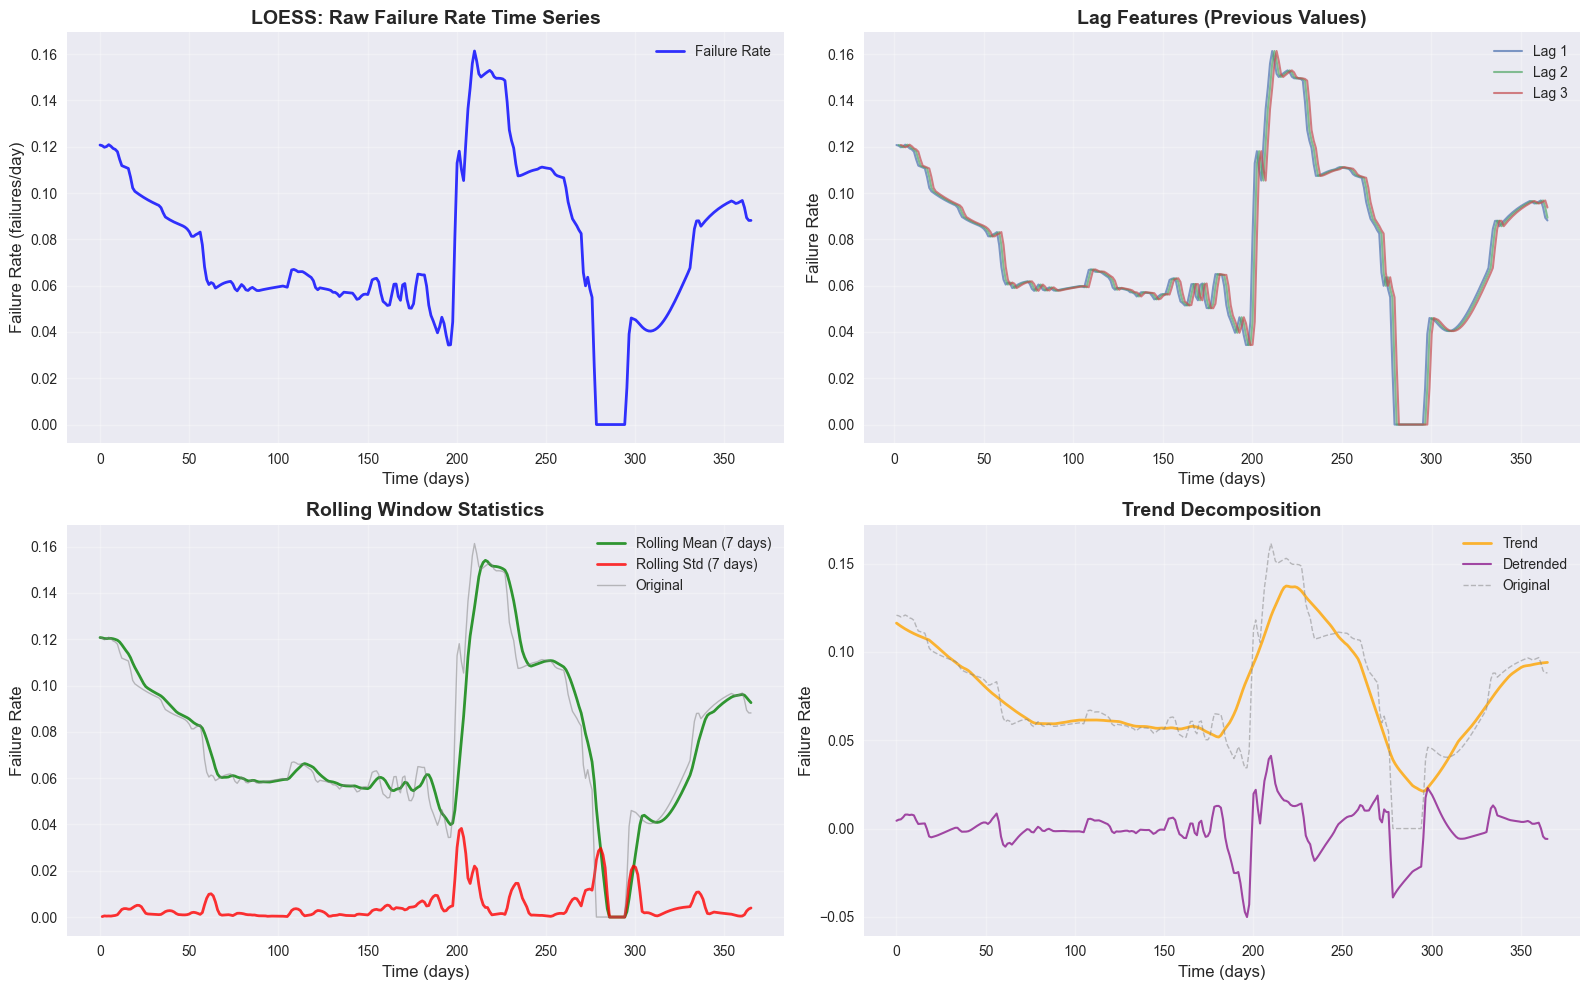


USAGE FOR TIME SERIES ML:

These features can be used directly in time series ML models:

1. **For LSTM/RNN/Transformer models:**
   - Use raw time series: ts_features['timeseries_data']['failure_rate']
   - Or use lag features: ts_features['failure_rate_lag_1'], lag_2, etc.
   - Add rolling statistics as additional features

2. **For ARIMA/Statistical models:**
   - Check autocorrelation: ts_features['autocorrelation']
   - Check stationarity: Use detrended_component
   - Use trend_component for trend analysis

3. **For Feature-based ML (XGBoost, Random Forest):**
   - Use all lag features
   - Use rolling statistics (mean, std, min, max)
   - Use volatility features
   - Use autocorrelation values
   - Use trend_strength, variance_change, etc.

4. **For Deep Learning:**
   - Use raw time series as input sequences
   - Add derived features as additional channels
   - Consider using trend and detrended components separately



In [110]:
# Extract time series features from all methods
timeseries_features_all = {}

for name, result in results.items():
    try:
        ts_features = result['model'].extract_timeseries_features()
        timeseries_features_all[name] = ts_features
        print(f"✓ {name}: Extracted time series features")
        print(f"  - Raw time series length: {len(ts_features['timeseries_data']['failure_rate'])}")
        print(f"  - Lag features: {sum(1 for k in ts_features.keys() if 'lag' in k)}")
        print(f"  - Rolling features: {sum(1 for k in ts_features.keys() if 'rolling' in k)}")
        print(f"  - Autocorrelation lags: {len(ts_features.get('autocorrelation', {}))}")
        print()
    except Exception as e:
        print(f"✗ {name}: Failed to extract time series features - {e}")

# Example: Get time series data from best method
best_method_name = ml_df.index[0]
best_ts_features = timeseries_features_all[best_method_name]

print("="*80)
print(f"TIME SERIES DATA FROM BEST METHOD: {best_method_name}")
print("="*80)
print(f"\nRaw Time Series Data:")
print(f"  Time points shape: {best_ts_features['timeseries_data']['time_points'].shape}")
print(f"  Failure rate shape: {best_ts_features['timeseries_data']['failure_rate'].shape}")
print(f"  Cumulative failures shape: {best_ts_features['timeseries_data']['cumulative_failures'].shape}")

print(f"\nAvailable Features:")
print(f"  - Lag features: {[k for k in best_ts_features.keys() if 'lag' in k]}")
print(f"  - Rolling statistics: {[k for k in best_ts_features.keys() if 'rolling' in k][:5]}...")
print(f"  - Autocorrelation: {list(best_ts_features.get('autocorrelation', {}).keys())}")
print(f"  - Volatility features: {[k for k in best_ts_features.keys() if 'volatility' in k or 'change' in k]}")
print(f"  - Trend features: {[k for k in best_ts_features.keys() if 'trend' in k or 'detrended' in k]}")

# Visualize time series features
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Raw time series
ax = axes[0, 0]
ts_data = best_ts_features['timeseries_data']
ax.plot(ts_data['time_points'], ts_data['failure_rate'], 
       linewidth=2, label='Failure Rate', color='blue', alpha=0.8)
ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Failure Rate (failures/day)', fontsize=12)
ax.set_title(f'{best_method_name}: Raw Failure Rate Time Series', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Lag features (first 3 lags)
ax = axes[0, 1]
for lag in [1, 2, 3]:
    lag_key = f'failure_rate_lag_{lag}'
    if lag_key in best_ts_features:
        lag_data = best_ts_features[lag_key]
        valid_mask = ~np.isnan(lag_data)
        if np.any(valid_mask):
            ax.plot(ts_data['time_points'][valid_mask], lag_data[valid_mask],
                   linewidth=1.5, label=f'Lag {lag}', alpha=0.7)
ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Failure Rate', fontsize=12)
ax.set_title('Lag Features (Previous Values)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Rolling statistics
ax = axes[1, 0]
if 'rolling_mean_7' in best_ts_features:
    ax.plot(ts_data['time_points'], best_ts_features['rolling_mean_7'],
           linewidth=2, label='Rolling Mean (7 days)', color='green', alpha=0.8)
if 'rolling_std_7' in best_ts_features:
    ax.plot(ts_data['time_points'], best_ts_features['rolling_std_7'],
           linewidth=2, label='Rolling Std (7 days)', color='red', alpha=0.8)
ax.plot(ts_data['time_points'], ts_data['failure_rate'],
       linewidth=1, label='Original', color='gray', alpha=0.5)
ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Failure Rate', fontsize=12)
ax.set_title('Rolling Window Statistics', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Trend decomposition
ax = axes[1, 1]
if 'trend_component' in best_ts_features:
    ax.plot(ts_data['time_points'], best_ts_features['trend_component'],
           linewidth=2, label='Trend', color='orange', alpha=0.8)
if 'detrended_component' in best_ts_features:
    ax.plot(ts_data['time_points'], best_ts_features['detrended_component'],
           linewidth=1.5, label='Detrended', color='purple', alpha=0.7)
ax.plot(ts_data['time_points'], ts_data['failure_rate'],
       linewidth=1, label='Original', color='gray', alpha=0.5, linestyle='--')
ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Failure Rate', fontsize=12)
ax.set_title('Trend Decomposition', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("USAGE FOR TIME SERIES ML:")
print("="*80)
print("""
These features can be used directly in time series ML models:

1. **For LSTM/RNN/Transformer models:**
   - Use raw time series: ts_features['timeseries_data']['failure_rate']
   - Or use lag features: ts_features['failure_rate_lag_1'], lag_2, etc.
   - Add rolling statistics as additional features

2. **For ARIMA/Statistical models:**
   - Check autocorrelation: ts_features['autocorrelation']
   - Check stationarity: Use detrended_component
   - Use trend_component for trend analysis

3. **For Feature-based ML (XGBoost, Random Forest):**
   - Use all lag features
   - Use rolling statistics (mean, std, min, max)
   - Use volatility features
   - Use autocorrelation values
   - Use trend_strength, variance_change, etc.

4. **For Deep Learning:**
   - Use raw time series as input sequences
   - Add derived features as additional channels
   - Consider using trend and detrended components separately
""")


## Key Takeaways

### Advantages of Non-Parametric Methods

1. **No Model Assumptions**: Don't need to assume power-law, exponential, or other distributions
2. **Automatic Adaptation**: Methods adapt to data patterns automatically
3. **Direct Failure Rate**: Derivative of cumulative = failure rate (no parameter interpretation needed)
4. **ML-Ready Features**: Extract features directly without model-specific parameters
5. **No Change Point Detection**: No need to find optimal piecewise segments
6. **Robust**: Work well even with noisy or irregular data

### Feature Extraction

All methods extract similar features:
- **Average failure rate**: Overall intensity
- **Failure rate slope**: Trend (positive = degrading, negative = improving)
- **Rate change ratio**: Early vs late period comparison
- **Peak failure rate**: Maximum intensity
- **Percentiles**: Distribution of failure rates
- **Variability measures**: CV, std, range

### When to Use Each Method

- **Savitzky-Golay**: Best for preserving local features while smoothing (recommended)
- **Moving Average**: Simplest, good for very noisy data
- **Gaussian Smoothing**: Good for smooth trends, less sensitive to outliers
- **LOESS**: Best for non-linear local patterns

### For ML Applications

These features can be used directly as:
- Input features for predictive models
- Comparison metrics (before/after PM)
- Trend indicators
- Equipment health scores

**No need for β, λ, or other parametric model parameters!**
